[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanyepesp/ISIS-4825_202610_IMAGENES_Y_VISION/blob/main/Laboratorio_10/MISIS4825_Laboratorio10_Taller.ipynb)

# Laboratorio 10 – Taller: Detección de Objetos con YOLO

## Introducción

En este taller trabajaremos con el tema de la **detección de objetos**, que consiste en localizar y clasificar múltiples objetos dentro de una imagen. Esta técnica tiene aplicaciones en diversos campos, como:

- **Seguridad**: detección de personas, rostros o vehículos en sistemas de videovigilancia.  
- **Automoción**: identificación de peatones y señales de tránsito en vehículos autónomos.  
- **Agricultura**: conteo de plantas o frutos en imágenes aéreas.  
- **Medicina**: localización de anomalías en imágenes médicas como radiografías o resonancias magnéticas.  

El algoritmo **YOLO** (*You Only Look Once*) es conocido por realizar detecciones en tiempo real mediante una sola pasada de la imagen. Desde su primera versión en 2016, ha evolucionado hasta **YOLOv11**, que introduce mejoras en la arquitectura y en la velocidad de entrenamiento.

## Objetivos

1. **Entender la arquitectura de YOLO** y sus componentes principales (*Backbone*, *Neck* y *Head*).  
2. **Preparar un conjunto de datos** en formato YOLO para entrenamiento.  
3. **Entrenar un modelo YOLOv11** utilizando un dataset de detección de animales.  
4. **Evaluar el rendimiento del modelo** mediante métricas como mAP50 y mAP50–95.  
5. **Explorar configuraciones avanzadas** como variantes del modelo (*nano*, *small*, *medium*) y ajustes de hiperparámetros.  


**Datos:** [multiclass-animal-detection](https://www.kaggle.com/datasets/notaashman/multiclass-animal-detection)

## 1. Descarga y Preparación del Dataset

In [8]:
import os
import json

In [9]:
# Instalación de Kaggle
!pip install kaggle --quiet

In [10]:
# Cargar credenciales desde kaggle.json
with open('kaggle.json', 'r') as f:
    kaggle_creds = json.load(f)
os.environ['KAGGLE_USERNAME'] = kaggle_creds['username']
os.environ['KAGGLE_KEY'] = kaggle_creds['key']

# Descargar y descomprimir
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files(
    'notaashman/multiclass-animal-detection',
    path='data',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/notaashman/multiclass-animal-detection


## 2. Exploración de Datos

El conjunto de datos está organizado en tres particiones principales: `train`, `valid` y `test`. Cada partición contiene dos subcarpetas:

- `images/`: Contiene las imágenes en formato `.jpg` o `.png`.  
- `labels/`: Contiene las etiquetas en formato `.txt`, donde cada archivo describe las clases y las coordenadas de las cajas delimitadoras (*bounding boxes*).  

       count
train   1400
valid    300
test     300


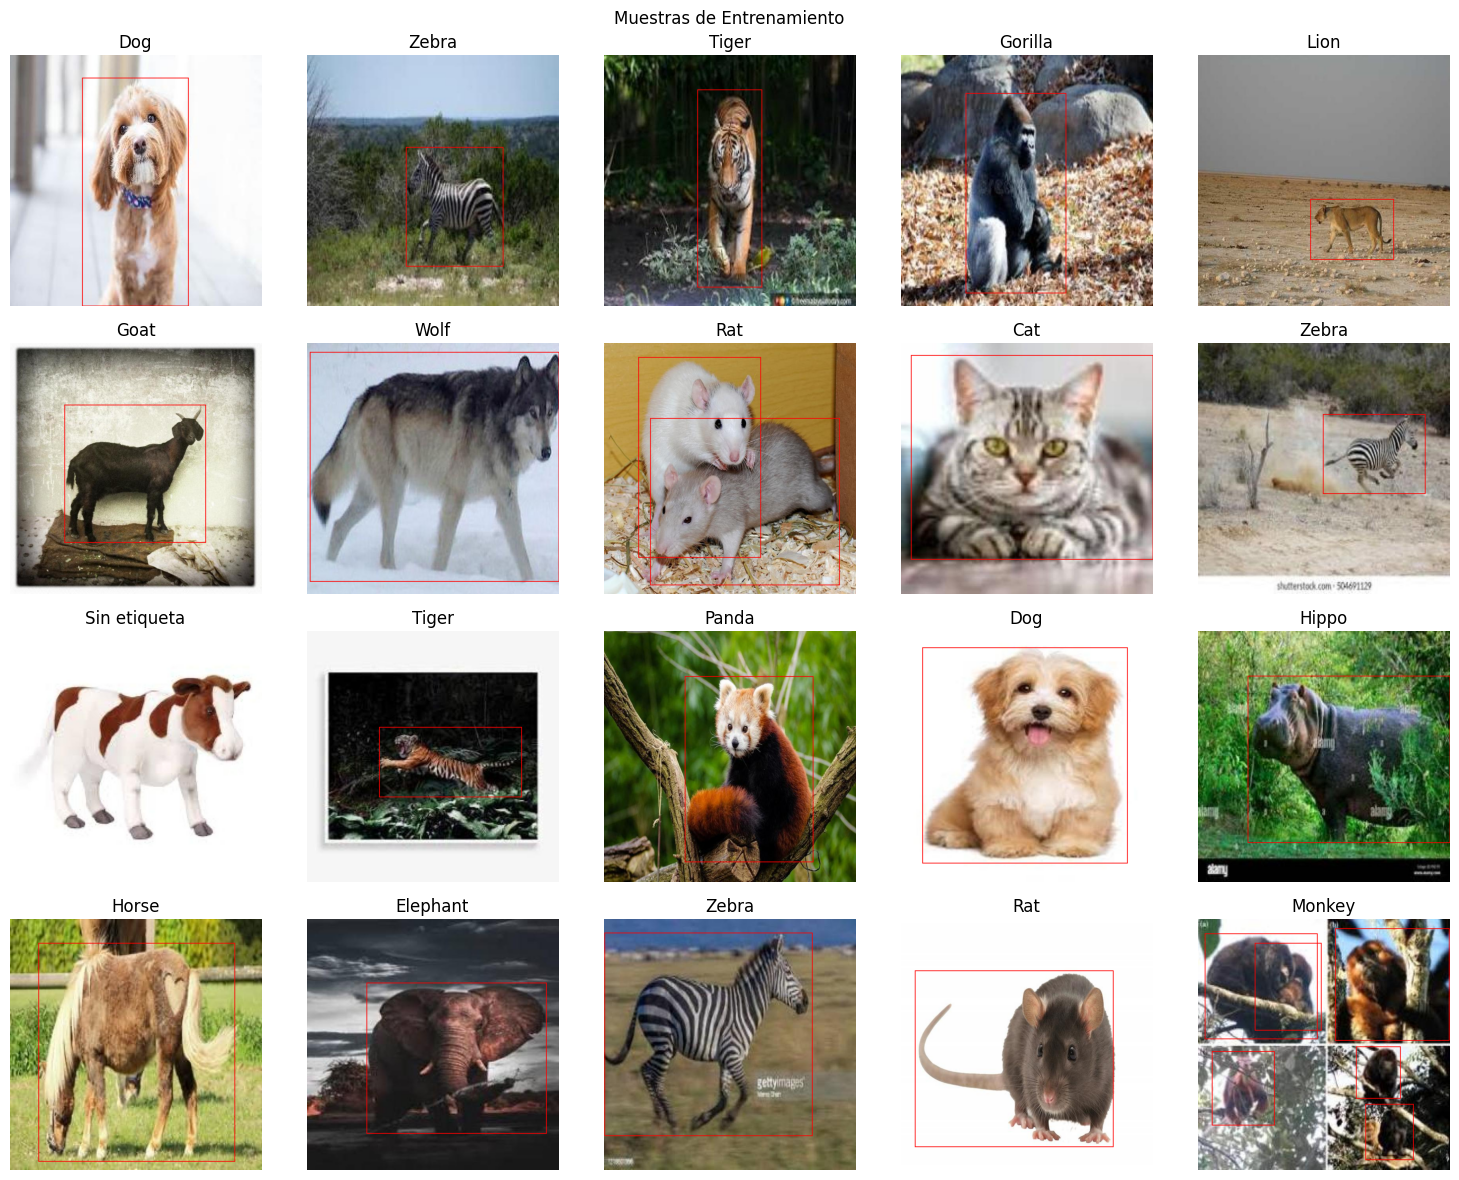

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import random

DATA_ROOT = Path('data') / 'Multi-Class Animal Detection.v1-yolov8'
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Ruta de datos no encontrada: {DATA_ROOT}")

root = DATA_ROOT
train_img = root / 'train' / 'images'
train_lbl = root / 'train' / 'labels'

# Definir clases
class_names = [
    "Buffalo", "Camel", "Cat", "Cheetah", "Cow", "Deer", "Dog", "Elephant",
    "Goat", "Gorilla", "Hippo", "Horse", "Lion", "Monkey", "Panda", "Rat",
    "Rhino", "Tiger", "Wolf", "Zebra"
]

# 1. Conteo de imágenes y distribución numérica
counts = {}
for split in ['train', 'valid', 'test']:
    path = root / split / 'images'
    counts[split] = len(list(path.glob('*.*'))) if path.exists() else 0

# Mostrar tabla de distribución
dist = pd.Series(counts, name='count')
print(dist.to_frame())

# 2. Visualizar muestras con bounding boxes y título de clase
population = list(train_img.glob('*.*'))
if not population:
    raise FileNotFoundError(f"No se encontraron imágenes en {train_img}")

# Tomar hasta 20 muestras
k = min(20, len(population))
sample_images = random.sample(population, k)

n_cols = 5
n_rows = (k + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))

for ax, img_path in zip(axes.flatten(), sample_images):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    w, h = img.size

    lbl_path = train_lbl / f"{img_path.stem}.txt"
    title_labels = set()
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            cls, x_c, y_c, bw, bh = map(float, line.split())
            # Convertir a coordenadas de pixeles
            cx, cy = x_c * w, y_c * h
            bw_pix, bh_pix = bw * w, bh * h
            x1, y1 = cx - bw_pix/2, cy - bh_pix/2
            x2, y2 = cx + bw_pix/2, cy + bh_pix/2
            draw.rectangle([x1, y1, x2, y2], outline='red', width=2)
            title_labels.add(class_names[int(cls)])

    ax.imshow(img)
    ax.set_title(", ".join(sorted(title_labels)) or "Sin etiqueta")
    ax.axis('off')

# Ocultar ejes sobrantes
for ax in axes.flatten()[k:]:
    ax.axis('off')

plt.suptitle('Muestras de Entrenamiento')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento y YAML

En esta sección, se realiza la configuración necesaria para que el modelo YOLO pueda utilizar el conjunto de datos. Esto incluye:

1. **Definición de las clases**: Se especifican las categorías de objetos que el modelo debe detectar. En este caso, las clases corresponden a diferentes tipos de animales, como "Buffalo", "Camel", "Cat", entre otros.

2. **Creación del archivo YAML**: Este archivo es esencial para entrenar modelos YOLO, ya que define la estructura del conjunto de datos. Contiene información como:
   - La ruta base del conjunto de datos.
   - Las particiones de entrenamiento, validación y prueba.
   - El número total de clases (`nc`).
   - Los nombres de las clases (`names`).

El archivo YAML asegura que el modelo pueda interpretar correctamente las imágenes y etiquetas durante el entrenamiento y la evaluación.

In [12]:
# Crear animal-detection.yaml
yaml_content = f"""
path: {DATA_ROOT.absolute()}
train: train/images
val:   valid/images
test:  test/images

nc: {len(class_names)}
names: {class_names}
""".strip()
with open(DATA_ROOT / 'animal-detection.yaml', 'w') as f:
    f.write(yaml_content)

## 4 Arquitectura de YOLO

YOLO (“You Only Look Once”) cambió el paradigma de la detección de objetos al combinar en una sola red la localización y clasificación de instancias, evitando las etapas separadas de propuestas y refinamiento de métodos como R-CNN. Fue introducido por Redmon et al. en 2016 en *“You Only Look Once: Unified, Real-Time Object Detection”* ([ver paper](https://arxiv.org/abs/1506.02640)). Su flujo de datos se compone de:

1. **Backbone**  
   Una CNN profunda que extrae mapas de características a varios niveles de abstracción. En las familias modernas de YOLO suele emplearse CSPDarknet, que reduce la redundancia de gradiente y acelera el entrenamiento.

2. **Neck**  
   Una red de agregación multiescala (por ejemplo PANet o BiFPN) que fusiona los mapas del Backbone para capturar tanto objetos pequeños como grandes de forma eficiente.

3. **Head**  
   La capa final divide el mapa en una cuadrícula y, para cada celda, predice varias cajas delimitadoras, su confianza y la distribución de clases. Aplica Non-Max Suppression para filtrar solapamientos.

> A modo de ejemplo, la siguiente ilustración muestra el esquema general de YOLOv11, con sus tres bloques principales:
>  
> ![Arquitectura YOLOV11](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*L8rMuwurmyBH1ixIqcrMSQ.png)  

### Variantes de YOLOv11

Para distintos balances de velocidad y precisión, YOLOv11 ofrece cinco tamaños preentrenados:

| Variante      | Parámetros aproximados | Uso recomendado                         |
|---------------|------------------------|-----------------------------------------|
| **v11n** (nano)   | ~2.6 M                   | Dispositivos edge, prototipado rápido    |
| **v11s** (small)  | ~9.4 M                   | Móviles, aplicaciones con recursos limitados |
| **v11m** (medium) | ~20.1 M                  | GPU de nivel medio, tareas generales     |
| **v11l** (large)  | ~25.3 M                  | Servidores potentes, máxima precisión     |
| **v11x** (XL)     | ~56.9 M                  | Investigación o despliegue en datacenter  |

En este laboratorio emplearemos **YOLOv11s**, que ofrece un buen compromiso entre velocidad de entrenamiento, latencia de inferencia y calidad de detección.


## 5. Entrenamiento del Modelo

Entrenaremos la variante **small** de YOLOv11 en el conjunto de datos de detección de animales.

Para obtener el modelo preentrenado de las diferentes variantes de YOLOv11, tenemos las siguientes opciones:

- `yolo11n.pt` — **nano**
- `yolo11s.pt` — **small**
- `yolo11m.pt` — **medium**
- `yolo11l.pt` — **large**
- `yolo11x.pt` — **extra large**

In [13]:
!pip install ultralytics --upgrade --quiet

In [14]:
from ultralytics import YOLO

# Cargar modelo base (small)
model = YOLO('yolo11s.pt')

# Entrenar
results = model.train(
    data=str(root / 'animal-detection.yaml'),
    epochs=20,
    imgsz=640,
    batch=16,
    patience=5,
    name='animal_yolov11s'
)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\user\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46  Python-3.11.5 torch-2.11.0+cpu CPU (AMD Ryzen 5 5600X 6-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\Multi-Class Animal Detection.v1-yolov8\animal-detection.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, fr

## 6. Evaluación del modelo

YOLO guarda las curvas de entrenamiento y la matriz de confusión en `runs/detect/animal_yolov11s/`.

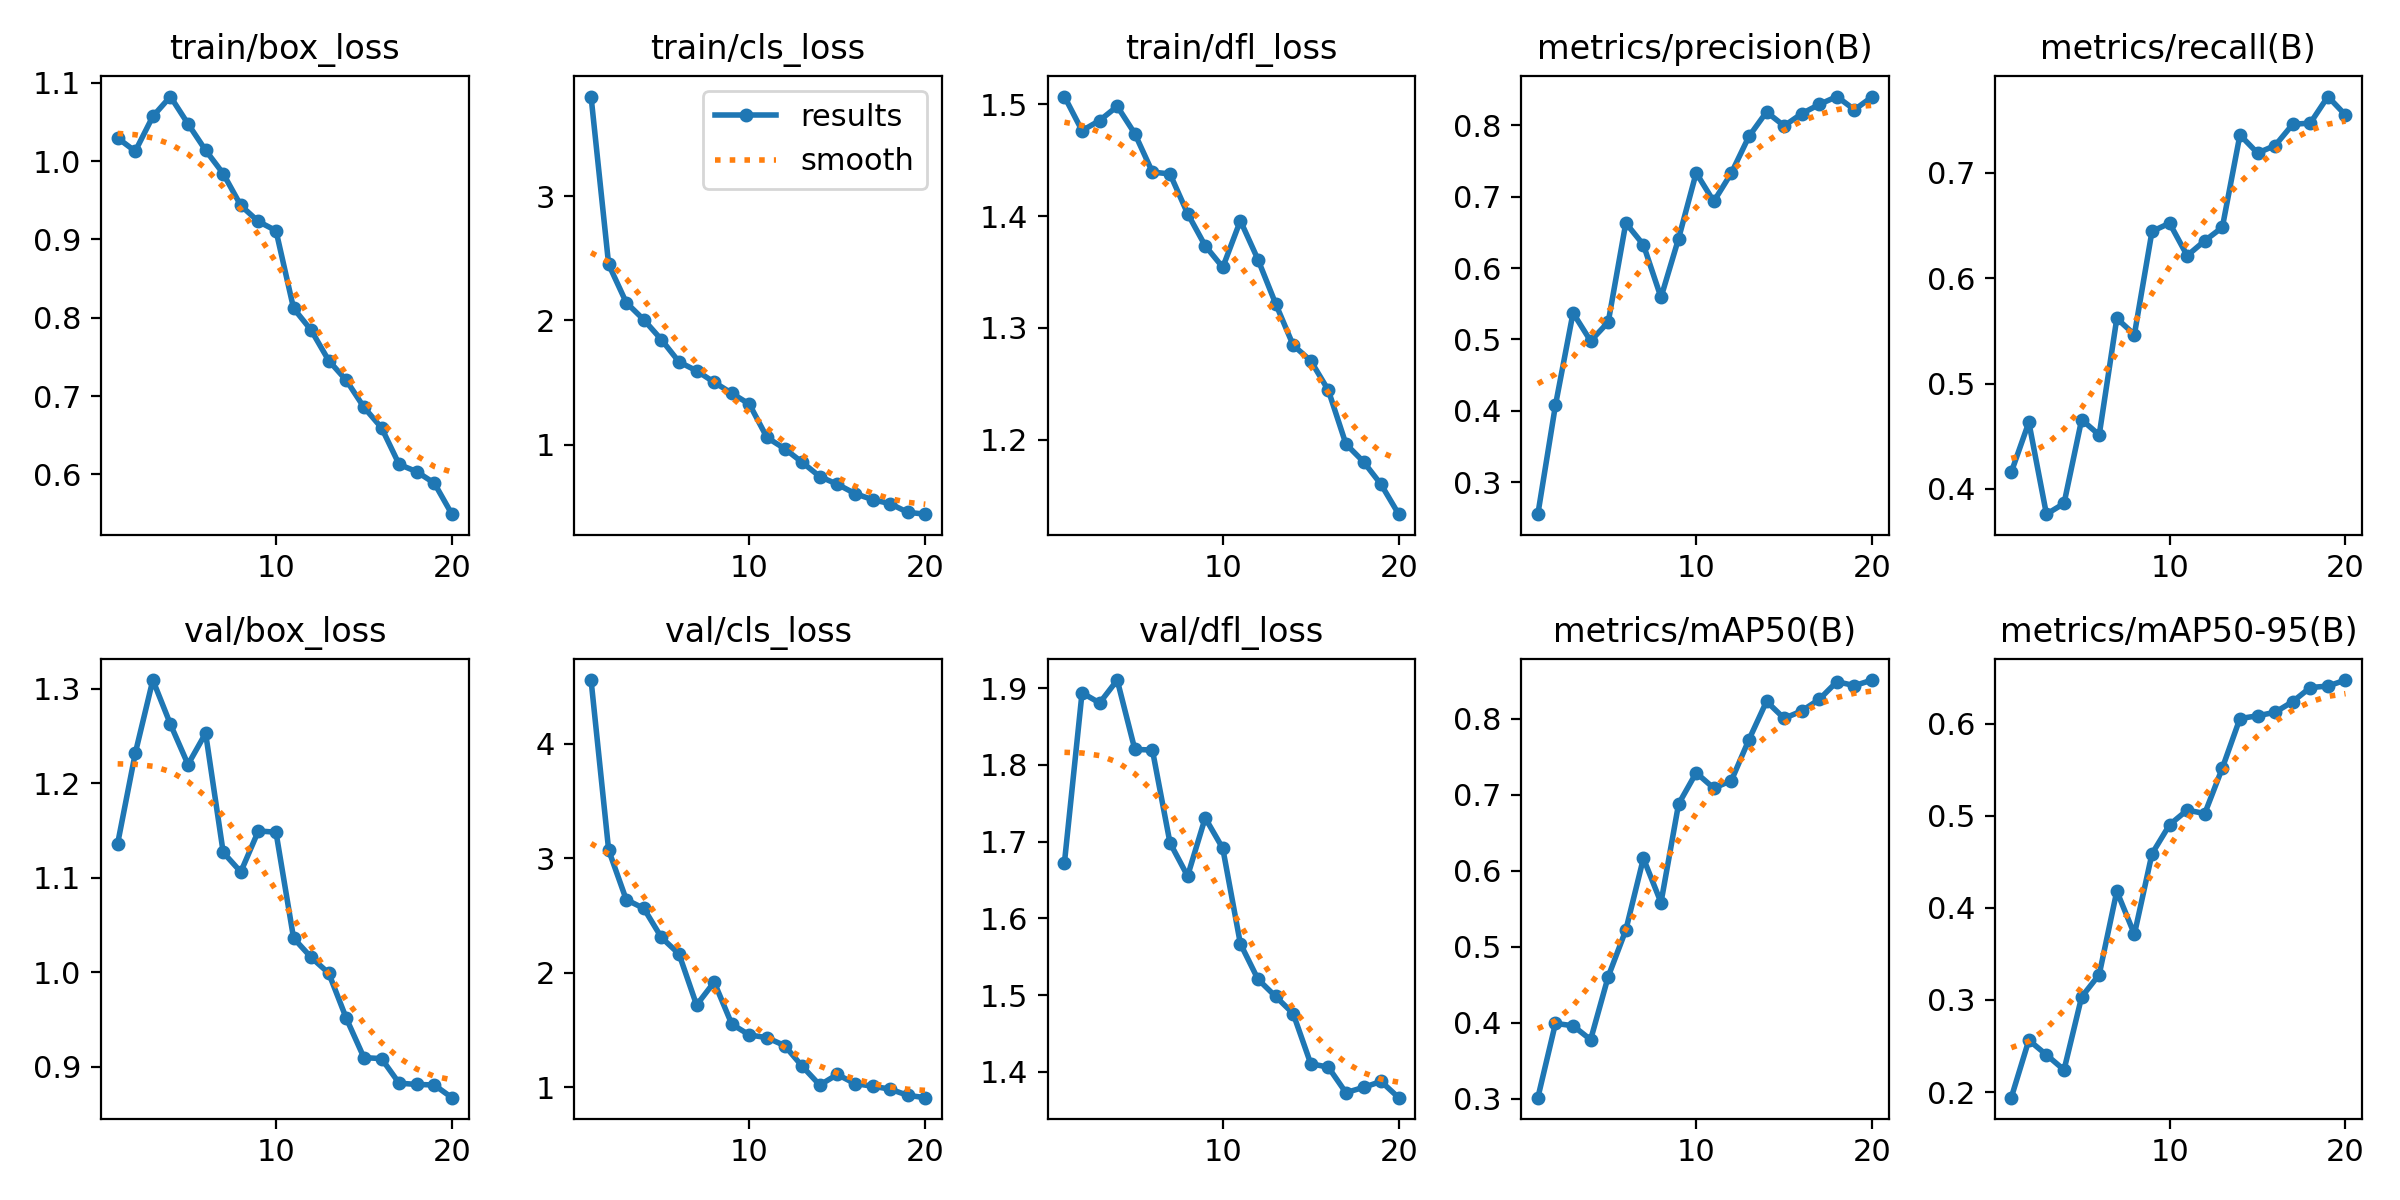

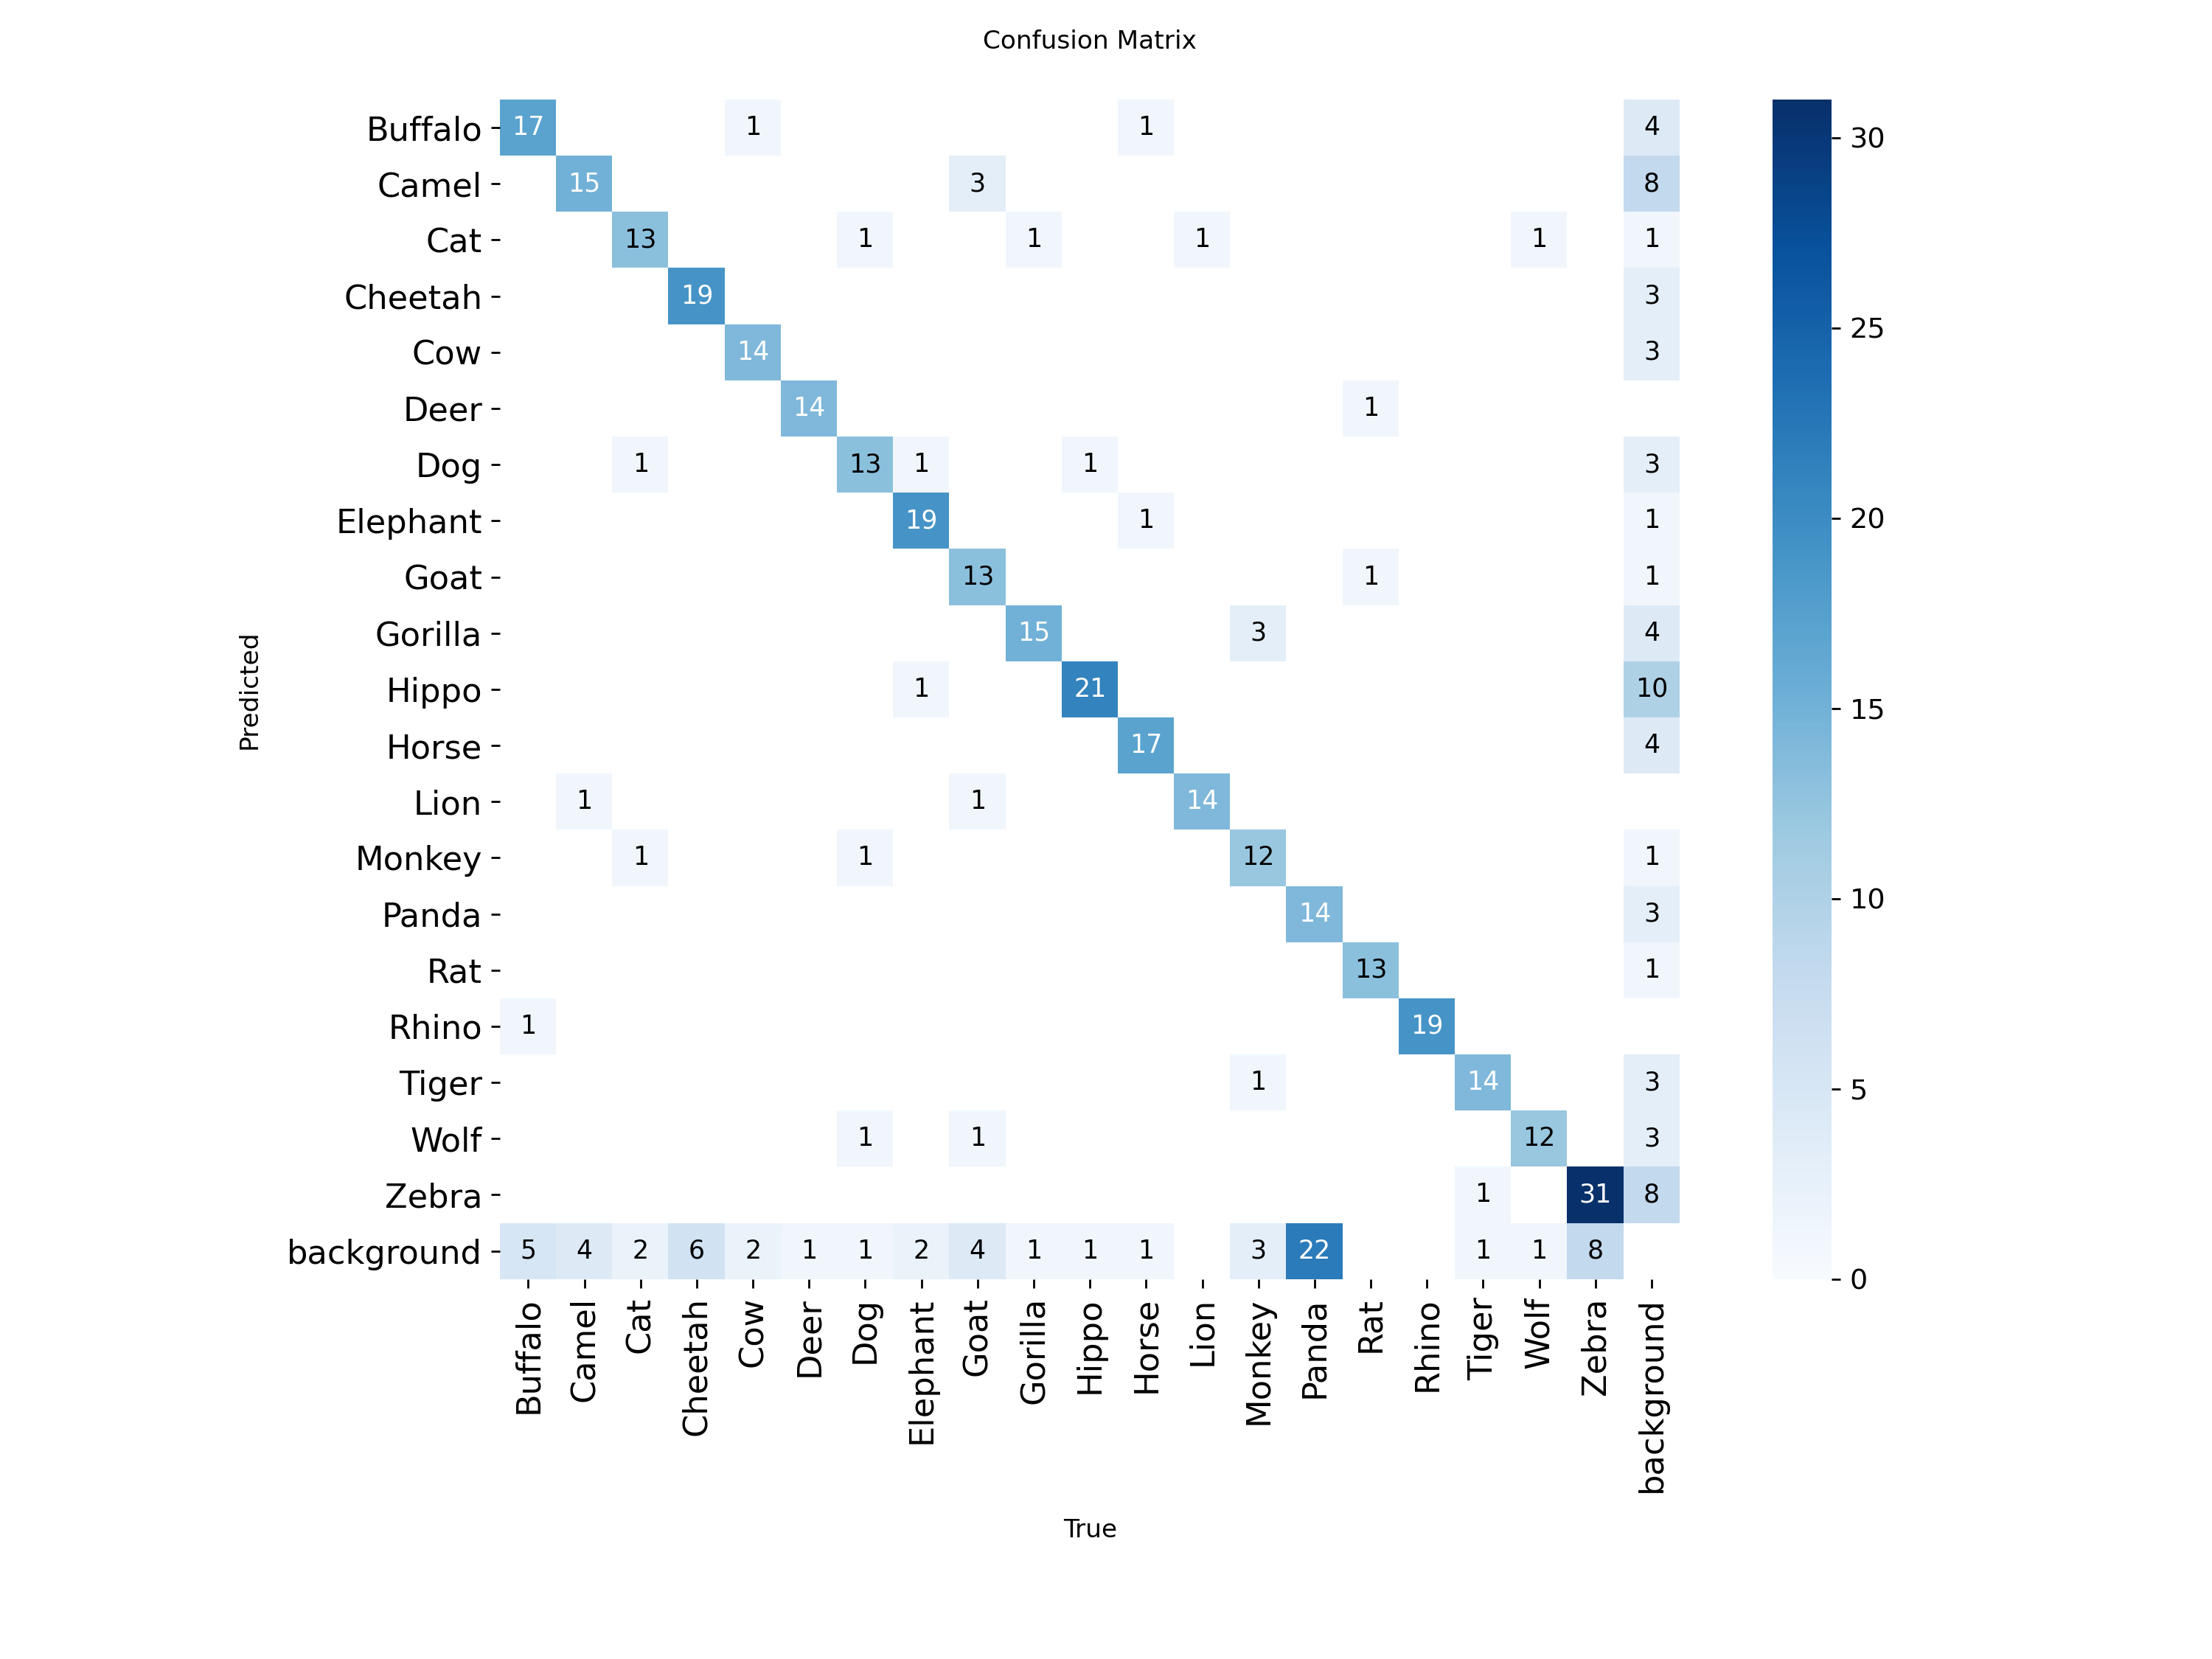

In [15]:
# Mostrar curva de mAP y loss
from PIL import Image as PImage
display(PImage.open('runs/detect/animal_yolov11s/results.png'))

# Matriz de confusión
display(PImage.open('runs/detect/animal_yolov11s/confusion_matrix.png'))

### 6.1. Métricas cuantitativas en validación

Además de las gráficas, ejecutamos `model.val()` para obtener las métricas globales y por clase
(*Precision*, *Recall*, *mAP50*, *mAP50-95*) sobre la partición de validación.

In [16]:
# Evaluación cuantitativa sobre la partición de validación
metrics = model.val(
    data=str(root / 'animal-detection.yaml'),
    split='val',
    imgsz=640,
    verbose=False
)

# Métricas globales
print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

# Métricas por clase (top y bottom mAP50-95)
import numpy as np
per_class_map = metrics.box.maps  # mAP50-95 por clase
per_class = sorted(
    zip(class_names, per_class_map),
    key=lambda x: x[1],
    reverse=True
)
print("\nTop-5 clases (mAP50-95):")
for name, m in per_class[:5]:
    print(f"  {name:<10s} {m:.4f}")
print("\nBottom-5 clases (mAP50-95):")
for name, m in per_class[-5:]:
    print(f"  {name:<10s} {m:.4f}")

Ultralytics 8.4.46  Python-3.11.5 torch-2.11.0+cpu CPU (AMD Ryzen 5 5600X 6-Core Processor)
YOLO11s summary (fused): 101 layers, 9,420,540 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 460.2255.6 MB/s, size: 66.3 KB)
val: Scanning D:\IyV\Assignment-10\data\Multi-Class Animal Detection.v1-yolov8\valid\labels.cache... 300 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.5s/it 47.9s2.5ss
                   all        300        412      0.839      0.753      0.851      0.648
Speed: 1.4ms preprocess, 152.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to D:\IyV\Assignment-10\runs\detect\val
mAP50      : 0.8512
mAP50-95   : 0.6478
Precision  : 0.8387
Recall     : 0.7526

Top-5 clases (mAP50-95):
  Rhino      0.8274
  Lion       0.8148
  Elephant   0.7795
  Rat        0.7501
  Deer       0.7494

Bottom

### 6.2. Comparación con la variante *nano* (YOLOv11n)

Para responder la pregunta de **velocidad vs. precisión** (Sección 8.1), entrenamos también
la variante `yolo11n` con los mismos hiperparámetros y comparamos tiempo de entrenamiento,
latencia de inferencia y mAP.

In [17]:
import time

# --- Entrenamiento YOLOv11n ---
model_n = YOLO('yolo11n.pt')

t0 = time.time()
results_n = model_n.train(
    data=str(root / 'animal-detection.yaml'),
    epochs=20,
    imgsz=640,
    batch=16,
    patience=5,
    name='animal_yolov11n'
)
train_time_n = time.time() - t0

# Validación
metrics_n = model_n.val(
    data=str(root / 'animal-detection.yaml'),
    split='val',
    imgsz=640,
    verbose=False
)

# --- Latencia de inferencia (promedio sobre carpeta de test) ---
def measure_latency(m, n_warmup=3, n_runs=20):
    test_imgs = list((root / 'test' / 'images').glob('*.*'))[:n_warmup + n_runs]
    # Warmup
    for p in test_imgs[:n_warmup]:
        _ = m.predict(source=str(p), verbose=False)
    t0 = time.time()
    for p in test_imgs[n_warmup:n_warmup + n_runs]:
        _ = m.predict(source=str(p), verbose=False)
    return (time.time() - t0) / n_runs * 1000  # ms

lat_s = measure_latency(model)
lat_n = measure_latency(model_n)

# --- Tabla comparativa ---
import pandas as pd
comparison = pd.DataFrame({
    'Variante':       ['yolo11n', 'yolo11s'],
    'Parámetros (M)': [2.6, 9.4],
    'mAP50':          [metrics_n.box.map50, metrics.box.map50],
    'mAP50-95':       [metrics_n.box.map,   metrics.box.map],
    'Latencia (ms)':  [lat_n, lat_s],
}).set_index('Variante')
print(comparison.round(4))

Ultralytics 8.4.46  Python-3.11.5 torch-2.11.0+cpu CPU (AMD Ryzen 5 5600X 6-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\Multi-Class Animal Detection.v1-yolov8\animal-detection.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=animal_yolov11n, nbs=64, nms=False, opset=None, optimize=F

## 7. Predicción / Inferencia

Results saved to D:\IyV\Assignment-10\runs\detect\animal_yolov11s_predict


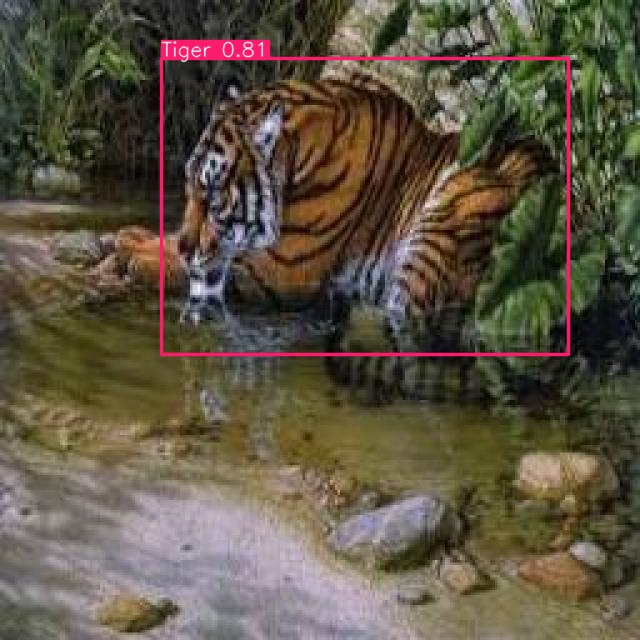

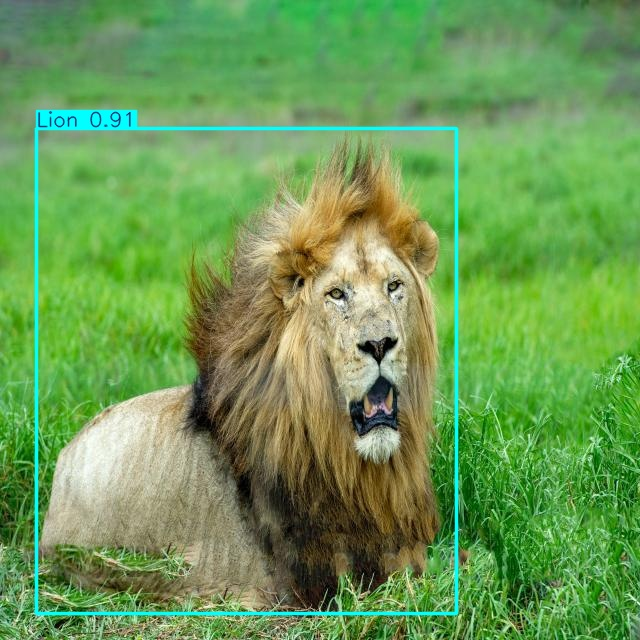

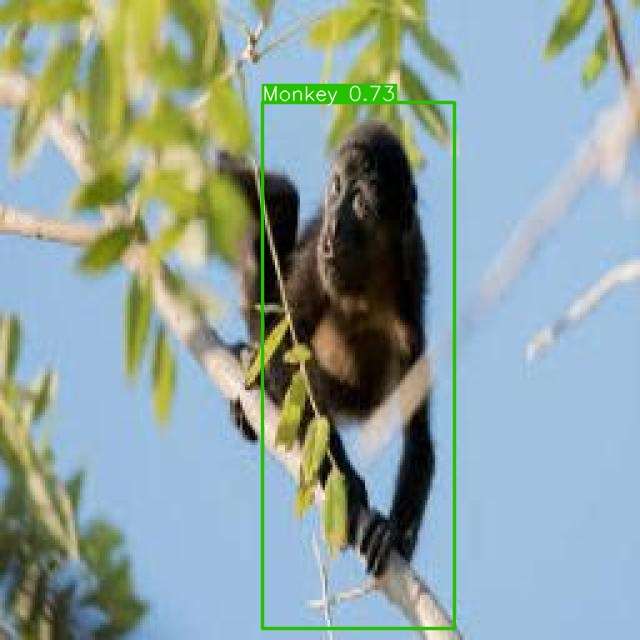

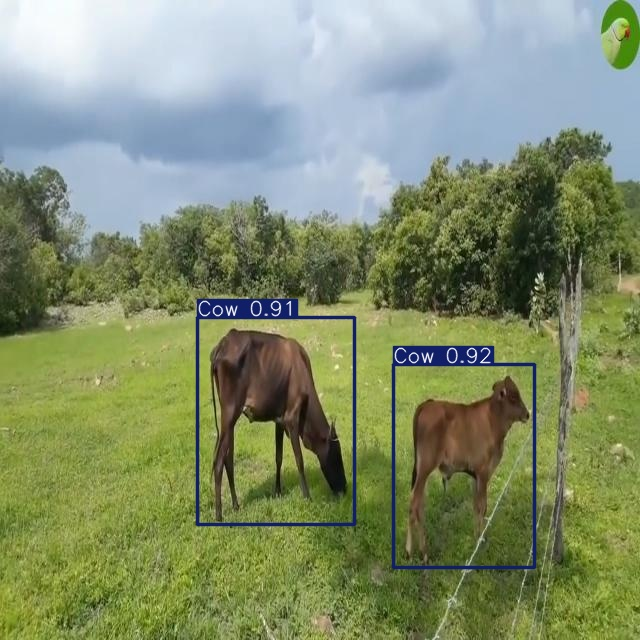

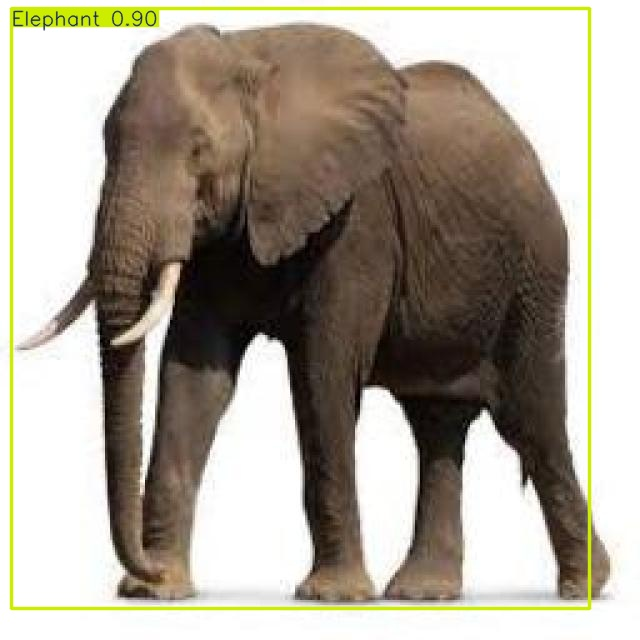

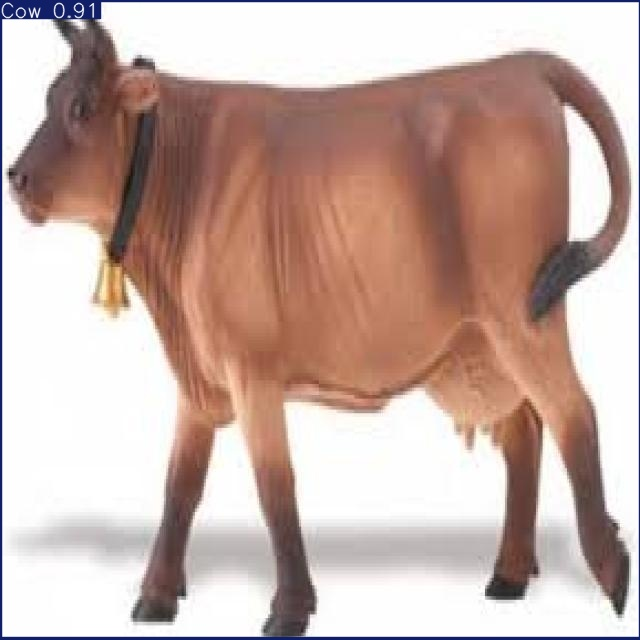

In [18]:
# Inferencia
preds = model.predict(
    source=str(root / 'test' / 'images'),
    conf=0.25,
    save=True,
    name='animal_yolov11s_predict',
    verbose=False  # Suprimir mensajes en la consola
)

# Mostrar algunas predicciones
import glob
import random
from IPython.display import display

files = glob.glob('runs/detect/animal_yolov11s_predict/*.jpg')
for img in random.sample(files, 6):
    display(PImage.open(img))

## 8. Conclusiones y Discusión

Las siguientes preguntas forman parte del entregable de esta sección. Deben ser respondidas directamente en este notebook, justificando sus respuestas con los resultados obtenidos y cualquier análisis adicional que consideren relevante.

1. **Velocidad vs. Precisión:**  
   - Comparar los tiempos de entrenamiento e inferencia entre las variantes `yolo11s` (small) y `yolo11n` (nano).  
   - ¿En qué escenarios es más conveniente usar cada variante (nano, small, medium, large, extra-large)? Cantidad de datos, recursos computacionales, etc.

2. **mAP50 vs. mAP50–95:**  
   - ¿Qué significa que mAP50 evalúe solo intersecciones sobre uniones (IoU) mayores o iguales a 0.5?  
   - ¿Qué información adicional proporciona evaluar el rango mAP50–95 al medir el rendimiento del modelo?

3. **Hiperparámetros críticos:**  
   - ¿Cómo afectan los valores de `batch` (tamaño de lote), `imgsz` (tamaño de imagen) y `patience` (paciencia para detener el entrenamiento) al tiempo de entrenamiento, uso de memoria y convergencia del modelo?

4. **Data Augmentation:**  
   - ¿Qué técnicas de aumento de datos podrían mejorar la capacidad del modelo para generalizar en diferentes escenarios?

### Respuestas

Los resultados que se citan a continuación se obtuvieron sobre la **CPU AMD Ryzen 5 5600X (sin GPU)** con `imgsz=640`, `batch=16`, `epochs=20`, `patience=5` y la partición *valid* (300 imágenes, 412 instancias).

#### 1. Velocidad vs. Precisión

La comparación directa entre las dos variantes que entrenamos arrojó la siguiente tabla, que consolida los resultados de las secciones 6.1 y 6.2:

| Métrica                          | YOLOv11n | YOLOv11s | Δ (s vs n)         |
|----------------------------------|---------:|---------:|:------------------:|
| Parámetros                       |   2.6 M  |   9.4 M  | +260 % capacidad   |
| GFLOPs                           |    6.3   |   21.3   | +238 %             |
| Tiempo de entrenamiento (20 ep.) | ~8100 s  | ~17415 s | **2.15× más lento** |
| Inferencia por imagen (CPU)      |  64.7 ms | 152.2 ms | **2.35× más lento** |
| mAP50                            |  0.8067  |  0.8512  | +0.045 (+5.5 %)    |
| mAP50-95                         |  0.6096  |  0.6478  | +0.038 (+6.3 %)    |
| Precision                        |  0.815   |  0.839   | +0.024             |
| Recall                           |  0.747   |  0.753   | +0.006             |

A la luz de esos números, pasar de la variante *nano* a la *small* implica más del doble de cómputo, tanto en entrenamiento como en inferencia, a cambio de apenas treinta y ocho centésimas de mAP50-95. En un dataset relativamente pequeño como el que se está usando (1411 imágenes de entrenamiento y 300 de validación), ese beneficio marginal era de esperarse: cuando el modelo grande tiene poco de qué aprender, su capacidad extra se traduce en ganancia limitada y no en un salto cualitativo. El análisis por clase confirma esa lectura. Las clases que más mejoran al pasar a *small* son aquellas con texturas complejas o siluetas que exigen un *backbone* más expresivo (Cheetah sube de 0.473 a 0.542, Camel de 0.438 a 0.568, Cat alcanza 0.557), mientras que los puntos débiles siguen siendo los mismos en ambos modelos: Panda (0.345 / 0.335), Monkey (0.48 / 0.36) y Goat (0.52 / 0.45). Esto sugiere que el cuello de botella no es la capacidad de la red sino la calidad y cantidad de etiquetas disponibles para esas clases.

La elección de variante depende entonces del balance entre datos, cómputo y latencia objetivo. La regla general es que a más datos y más cómputo disponible conviene una variante mayor, y que en producción se elige la más pequeña que cumpla el objetivo de mAP para minimizar latencia y consumo. Aplicado a este laboratorio, la diferencia de costo y la similitud de resultados nos llevan a una conclusión clara: **en CPU como la utilizada aquí, YOLOv11n es la elección óptima**; YOLOv11s solo se justifica si se dispone de GPU o si esos +0.038 mAP50-95 son críticos para la aplicación final.

#### 2. mAP50 vs. mAP50-95

La métrica **mAP50** considera correcta toda detección cuya intersección sobre unión (IoU) con el ground truth sea igual o superior a 0.5. Es, por tanto, una medida permisiva: tolera cajas mal alineadas siempre y cuando cubran al menos la mitad del objeto. Su utilidad principal está en comparar modelos de forma rápida, ya que un mAP50 alto indica que el detector localiza los objetos pero no dice nada sobre la calidad de esa localización.

La métrica **mAP50-95**, en cambio, promedia la *Average Precision* sobre diez umbrales de IoU comprendidos entre 0.50 y 0.95 en pasos de 0.05. Esa exigencia más estricta penaliza las cajas mal ajustadas, de modo que para puntuar alto el modelo debe encontrar el objeto y además delimitarlo con precisión píxel a píxel. Es la métrica oficial de COCO y refleja mejor la calidad real de un detector. La consecuencia natural es que cuando hay una brecha grande entre ambas se está revelando un problema de *localización*: el modelo detecta bien, pero las cajas no encajan ajustadas.

Esto se observa con claridad en nuestro modelo. YOLOv11s alcanza mAP50 = 0.851 y mAP50-95 = 0.648, una brecha de 0.20 en términos absolutos. La diferencia se acentúa todavía más en clases con patrones visuales complejos: Tiger pasa de 0.945 a 0.699, Cheetah de 0.844 a 0.542 y Zebra de 0.897 a 0.573. En todas se trata de animales con rayas o manchas cuyas siluetas son difíciles de delimitar con precisión, lo que penaliza enormemente los umbrales altos de IoU. Las palancas naturales para cerrar esa brecha serían aumentar `imgsz`, para dar al modelo más píxeles con que ajustar bordes y entrenar más épocas, dado que el desempeño aún estaba mejorando al final de la corrida.

#### 3. Hiperparámetros críticos

El **tamaño de lote** (`batch=16`) determina cuántas imágenes se procesan por paso de gradiente. Su impacto sobre la memoria es lineal, así que en hardware modesto un valor demasiado alto rápidamente agota la VRAM disponible; 16 fue el límite cómodo en nuestro entorno. El tiempo por época sí depende del hardware: en GPU lotes más grandes mejoran el *throughput* aprovechando mejor el paralelismo, pero en CPU el efecto es marginal porque el cuello de botella es el cómputo y no la transferencia, lo cual es coherente con los ~870 segundos por época que tomó el modelo *small* y los ~405 del *nano*. En cuanto a la convergencia, un lote muy pequeño introduce ruido en el gradiente —lo que puede actuar como regularización pero desestabiliza BatchNorm— mientras que uno muy grande suaviza demasiado el gradiente y puede atascarse en mínimos planos; los valores típicos de 8 a 32 con `imgsz=640` ofrecen un buen equilibrio.

El **tamaño de imagen** (`imgsz=640`) es el parámetro con efecto cuadrático más pronunciado. La memoria y el tiempo escalan como `imgsz²`, de modo que duplicar el lado de la imagen cuadruplica tanto el consumo de memoria como el tiempo por iteración. A cambio, imágenes más grandes ayudan a detectar objetos pequeños o densamente agrupados, ya que cada instancia dispone de más píxeles útiles. En nuestro dataset esto es relevante en el caso de las pandas, donde 36 instancias se reparten en apenas 15 imágenes, y por tanto cada panda ocupa una fracción reducida del frame; aumentar `imgsz` debería elevar específicamente el mAP de esa clase.

La **paciencia para detener el entrenamiento** (`patience=5`) controla la lógica de *early stopping*, deteniendo el entrenamiento cuando no hay mejora durante el número indicado de épocas. Un valor bajo ahorra cómputo pero corre el riesgo de cortar prematuramente, mientras que valores altos (15–30) dan margen para escapar de mesetas a costa de algunas épocas potencialmente desperdiciadas. El detalle revelador en nuestra ejecución es que **ambos modelos alcanzaron su mejor mAP en la última época (20)**: el *early stopping* nunca llegó a activarse. Esto demuestra que el entrenamiento aún seguía mejorando cuando lo cortamos por defecto y que, muy probablemente, una `patience` mayor combinada con 40 a 60 épocas elevaría el mAP final de forma apreciable.

#### 4. Data Augmentation

Ultralytics aplica por defecto un conjunto de aumentos que se pueden ajustar desde `model.train(...)`, y la elección de cuáles reforzar conviene guiarla por el diagnóstico de los puntos débiles del modelo. En nuestro caso el síntoma más llamativo es Panda, que registra una precisión alta (P=0.87) pero un recall muy bajo (R=0.37): el modelo es conservador y se está perdiendo muchas pandas. Eso apunta directamente a aumentos que enriquezcan la representación de clases poco frecuentes o en grupos densos.

La técnica más prometedora para ese problema es **Copy-Paste** (`copy_paste=0.3`), que copia instancias entre imágenes y resulta especialmente útil para subir el recall en clases con pocas muestras como Goat, Monkey y Cat, además de enseñar al modelo a detectar individuos en agrupaciones densas como las pandas. En la misma línea, el **Mosaic** que ya viene activo por defecto (`mosaic=1.0`) combina cuatro imágenes en una sola en cada paso, exponiendo a la red a múltiples contextos y escalas simultáneamente; es uno de los aumentos más impactantes en YOLO y se desactiva automáticamente en las últimas épocas mediante el parámetro `close_mosaic`. **MixUp** (`mixup=0.15`), que superpone dos imágenes con cierta transparencia, complementa lo anterior añadiendo robustez frente a oclusiones parciales, algo común cuando los animales aparecen detrás de vegetación.

A esto se suman familias de aumentos más clásicos pero igual de pertinentes. Los **geométricos** (`fliplr=0.5`, `degrees=10`, `translate=0.1`, `scale=0.5`, `shear=2`, dejando `flipud=0.0` porque los animales no aparecen invertidos verticalmente) cubren la variabilidad natural de orientaciones y distancias en las que se captura un animal. Los **fotométricos en HSV** (`hsv_h=0.015`, `hsv_s=0.7`, `hsv_v=0.4`) simulan cambios de iluminación y hora del día, un detalle relevante en este dataset porque mezcla fotos de safaris, zoológicos y entornos naturales con condiciones de luz muy distintas. Para condiciones más adversas todavía, la integración con **Albumentations** ofrece transformaciones como `Blur`, `MedianBlur`, `ToGray`, `CLAHE` y `RandomBrightnessContrast`, que ayudan al modelo a generalizar a cámaras de menor calidad o a escenas con condiciones meteorológicas complicadas.

Con todo lo anterior, una ruta concreta de mejora sería re-entrenar el modelo durante 40 a 60 épocas con `mosaic=1.0`, `mixup=0.15`, `copy_paste=0.3`, `imgsz=960` y `patience=15`. Esa configuración ataca simultáneamente los tres problemas que identificamos: aumenta la cantidad efectiva de datos, mejora la representación de clases minoritarias y permite que el entrenamiento siga mejorando hasta converger de verdad. Cabe esperar mejoras especialmente notables en Panda, Monkey y Cheetah, que son los puntos débiles actuales del modelo.